# 6-2 How to Find and Select a Dataset for ML Project

# 6-3 Setup and Data Loading


In [2]:
#Import Necessary Library
import numpy as pd
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


plt.style.use("default")
sns.set(font_scale=1.1)
from google.colab import files


In [3]:
# Upload hear.csv from computer
uploaded = files.upload()
df = pd.read_csv("heart.csv")
df.head(10)

Saving heart.csv to heart.csv


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
5,39,M,NAP,120,339,0,Normal,170,N,0.0,Up,0
6,45,F,ATA,130,237,0,Normal,170,N,0.0,Up,0
7,54,M,ATA,110,208,0,Normal,142,N,0.0,Up,0
8,37,M,ASY,140,207,0,Normal,130,Y,1.5,Flat,1
9,48,F,ATA,120,284,0,Normal,120,N,0.0,Up,0


In [4]:
# Basic information about rows, columns, and data types
print(df.shape)
print(df.info())

(918, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB
None


In [5]:
# Quick description statistics for numeric columns
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,918.0,53.510893,9.432617,28.0,47.00,54.0,60.0,77.0
RestingBP,918.0,132.396514,18.514154,0.0,120.00,130.0,140.0,200.0
Cholesterol,918.0,198.799564,109.384145,0.0,173.25,223.0,267.0,603.0
FastingBS,918.0,0.233115,0.423046,0.0,0.00,0.0,0.0,1.0
MaxHR,918.0,136.809368,25.460334,60.0,120.00,138.0,156.0,202.0
Oldpeak,918.0,0.887364,1.066570,-2.6,0.00,0.6,1.5,6.2
HeartDisease,918.0,0.553377,0.497414,0.0,0.00,1.0,1.0,1.0


In [6]:
#Define target and feature types
target_col = "HeartDisease"
numeric_col = ["Age", "RestingBP", "Cholesterol", "FastingBS", "MaxHR", "Oldpeak"]
categorical_cols= ["Sex", "ChestPainType", "RestingECG", "ExerciseAngina", "ST_Slope"]

print(target_col)
print(numeric_col)
print(categorical_cols)

HeartDisease
['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak']
['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']


# 6-4 Missing Values and Basic Quality Checks

In [7]:
#Check missing values count per column
df.isna().sum()

,0
Age,0
Sex,0
ChestPainType,0
RestingBP,0
Cholesterol,0
FastingBS,0
RestingECG,0
MaxHR,0
ExerciseAngina,0
Oldpeak,0


In [8]:
#look at some basic vlue ranges
df[numeric_col].agg(["min", "max", "mean", "median"]).T


,min,max,mean,median
Age,28.0,77.0,53.510893,54.0
RestingBP,0.0,200.0,132.396514,130.0
Cholesterol,0.0,603.0,198.799564,223.0
FastingBS,0.0,1.0,0.233115,0.0
MaxHR,60.0,202.0,136.809368,138.0
Oldpeak,-2.6,6.2,0.887364,0.6


In [9]:
for c in categorical_cols:
  print(c, df[c].unique())

Sex ['M' 'F']
ChestPainType ['ATA' 'NAP' 'ASY' 'TA']
RestingECG ['Normal' 'ST' 'LVH']
ExerciseAngina ['N' 'Y']
ST_Slope ['Up' 'Flat' 'Down']


# 6-5 Understanding Distributions with Histograms and Boxplots [Numerical Features]

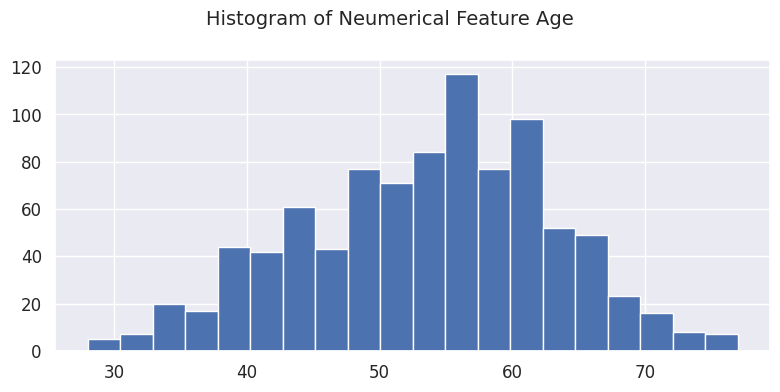

In [10]:
# Histogram for numeric features
df["Age"].hist(bins = 20, figsize = (8,4))
plt.suptitle("Histogram of Neumerical Feature Age", fontsize = 14)
plt.tight_layout()
plt.show()

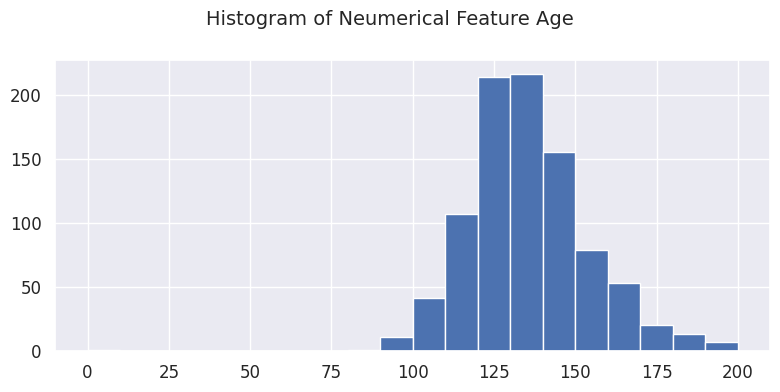

In [11]:
df["RestingBP"].hist(bins = 20, figsize = (8,4))
plt.suptitle("Histogram of Neumerical Feature Age", fontsize = 14)
plt.tight_layout()
plt.show()

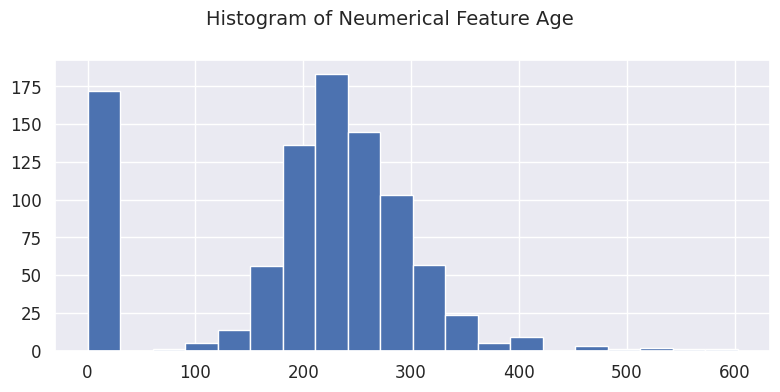

In [12]:
df["Cholesterol"].hist(bins = 20, figsize = (8,4))
plt.suptitle("Histogram of Neumerical Feature Age", fontsize = 14)
plt.tight_layout()
plt.show()

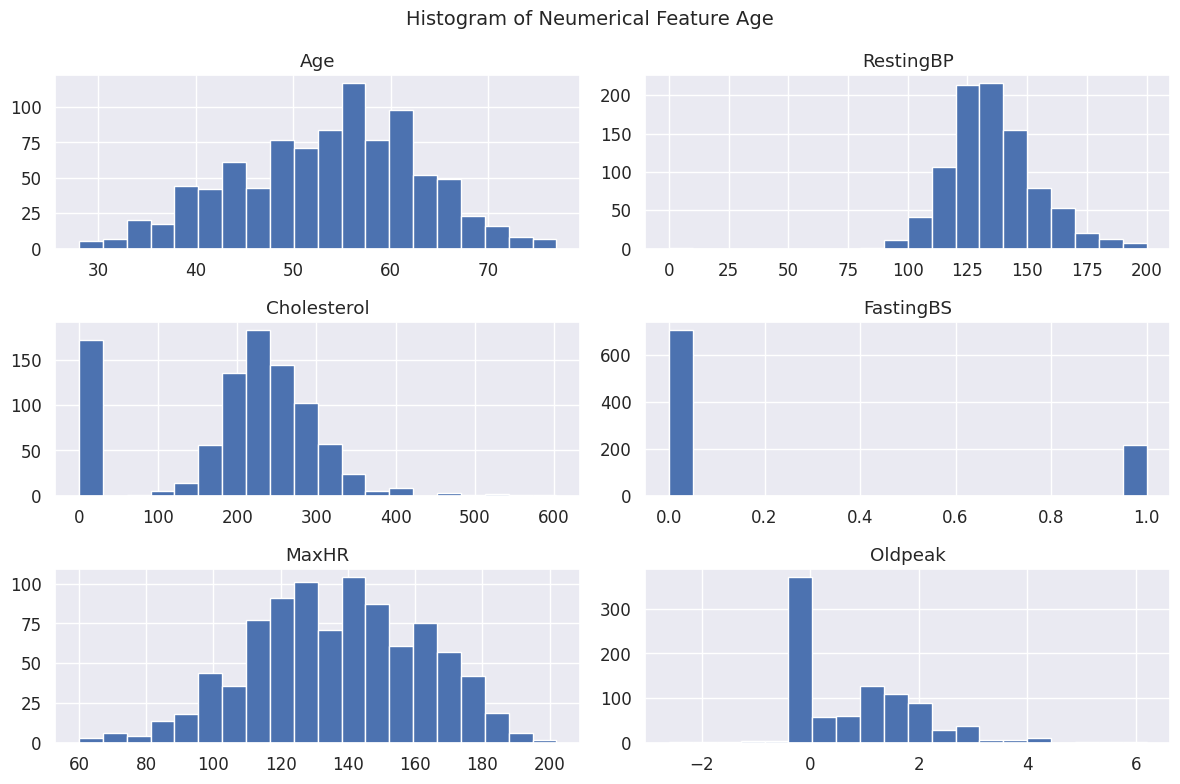

In [13]:
df[numeric_col].hist(bins = 20, figsize = (12,8))
plt.suptitle("Histogram of Neumerical Feature Age", fontsize = 14)
plt.tight_layout()
plt.show()

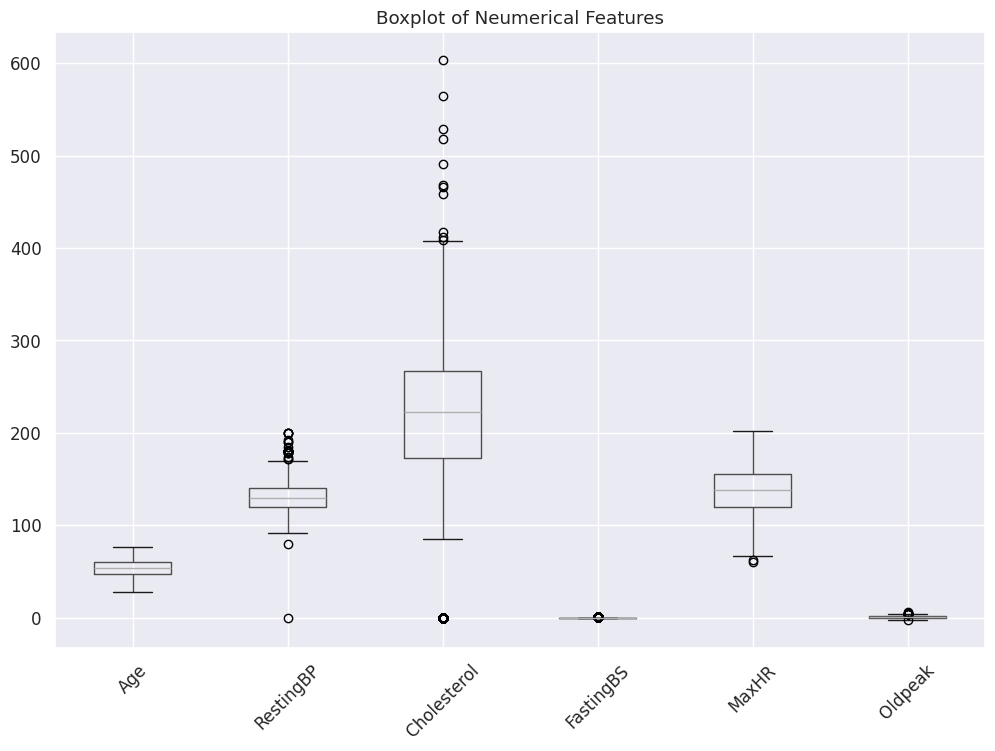

In [14]:
# Boxplots to get a sense of spread and possible outliers
plt.figure(figsize=(12,8))
df.boxplot(column = numeric_col)
plt.title("Boxplot of Neumerical Features")
plt.xticks(rotation = 45)
plt.show()

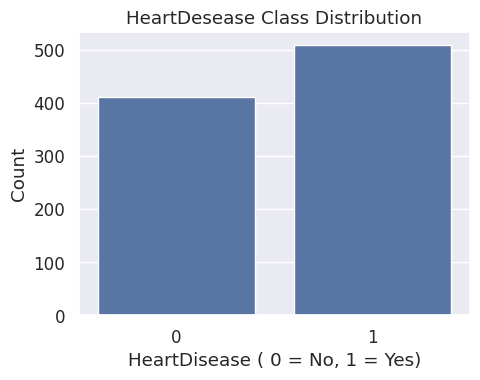

In [15]:
#Target Distribution and class Imbalance
plt.figure(figsize=(5,4))
sns.countplot(x = df[target_col])
plt.title("HeartDesease Class Distribution")
plt.xlabel("HeartDisease ( 0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [16]:
df[target_col].value_counts(normalize=True)

,proportion
HeartDisease,
1,0.553377
0,0.446623


# 6-6 Categorical Feature Exploration

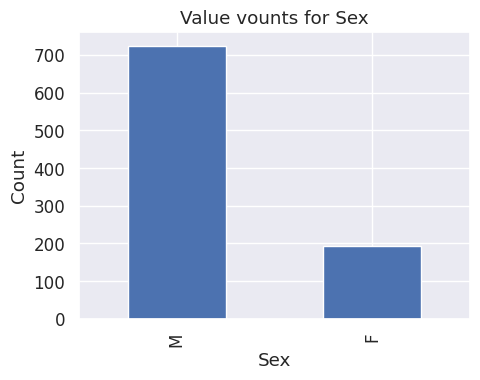

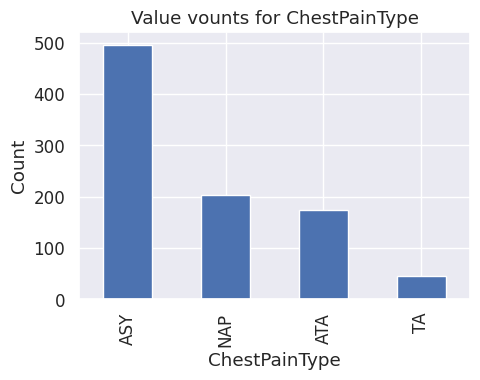

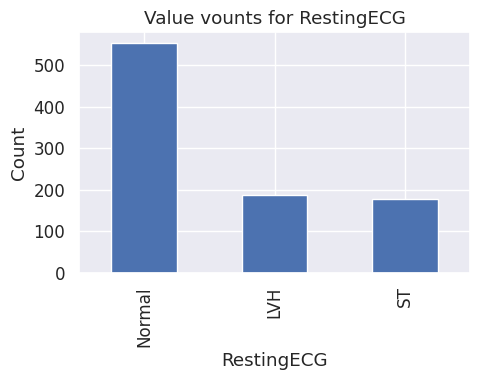

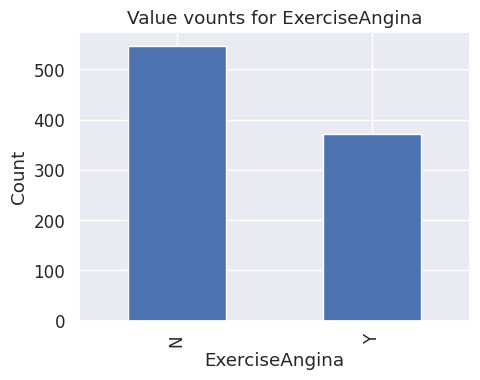

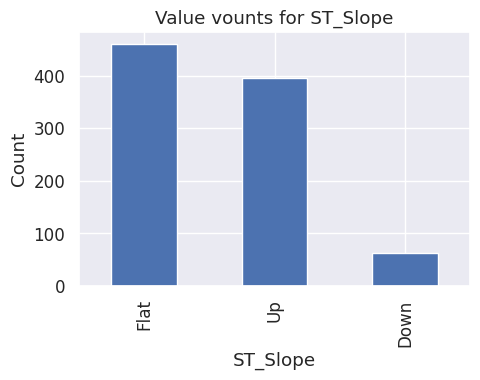

In [17]:
#Catergorical Feature Ecploration
for c in categorical_cols:
  plt.figure(figsize = (5,4))
  df[c].value_counts().plot(kind = "bar")
  plt.title(f"Value vounts for {c}")
  plt.ylabel("Count")
  plt.tight_layout()
  plt.show()

# 6-7 Relationships Between Features and Target Part 01

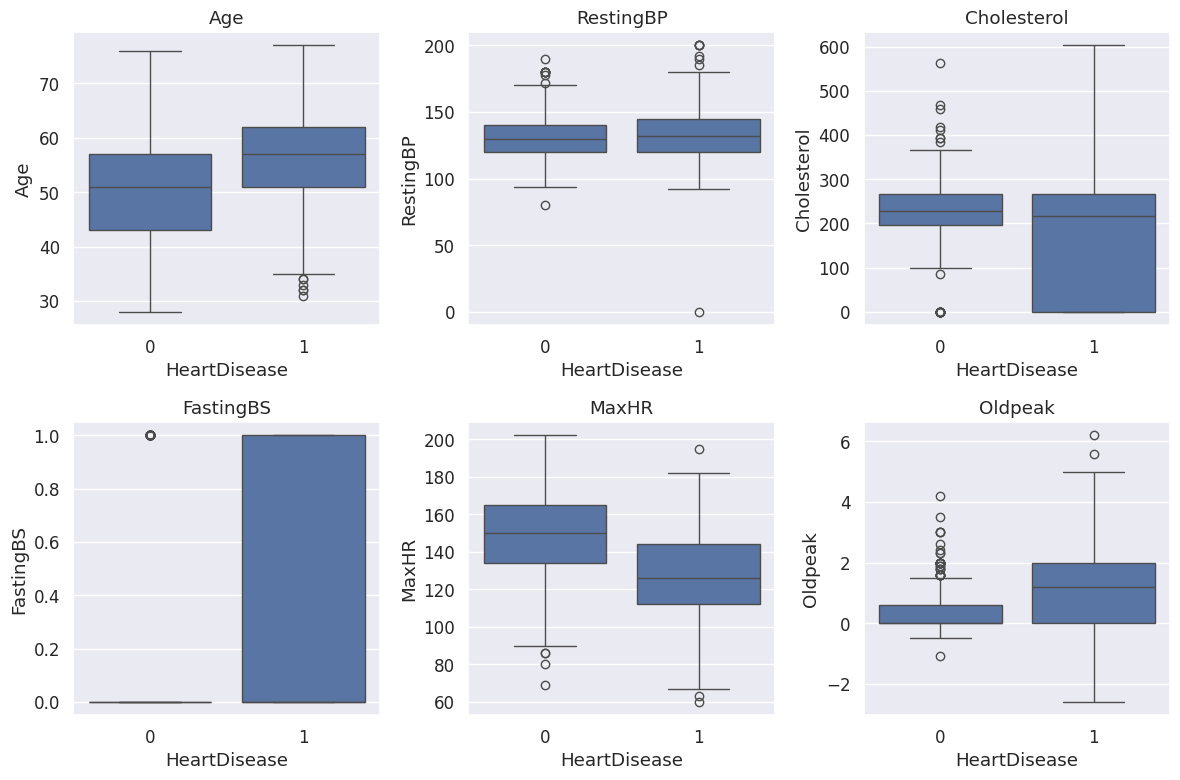

In [18]:
# Boxplots of numeric features split by Heartdisease.
plt.figure(figsize=(12,8))
for i, col in enumerate(numeric_col,1):
  plt.subplot(2,3,i)
  sns.boxplot(x = df[target_col], y = df[col])
  plt.title(col)


plt.tight_layout()
plt.show()

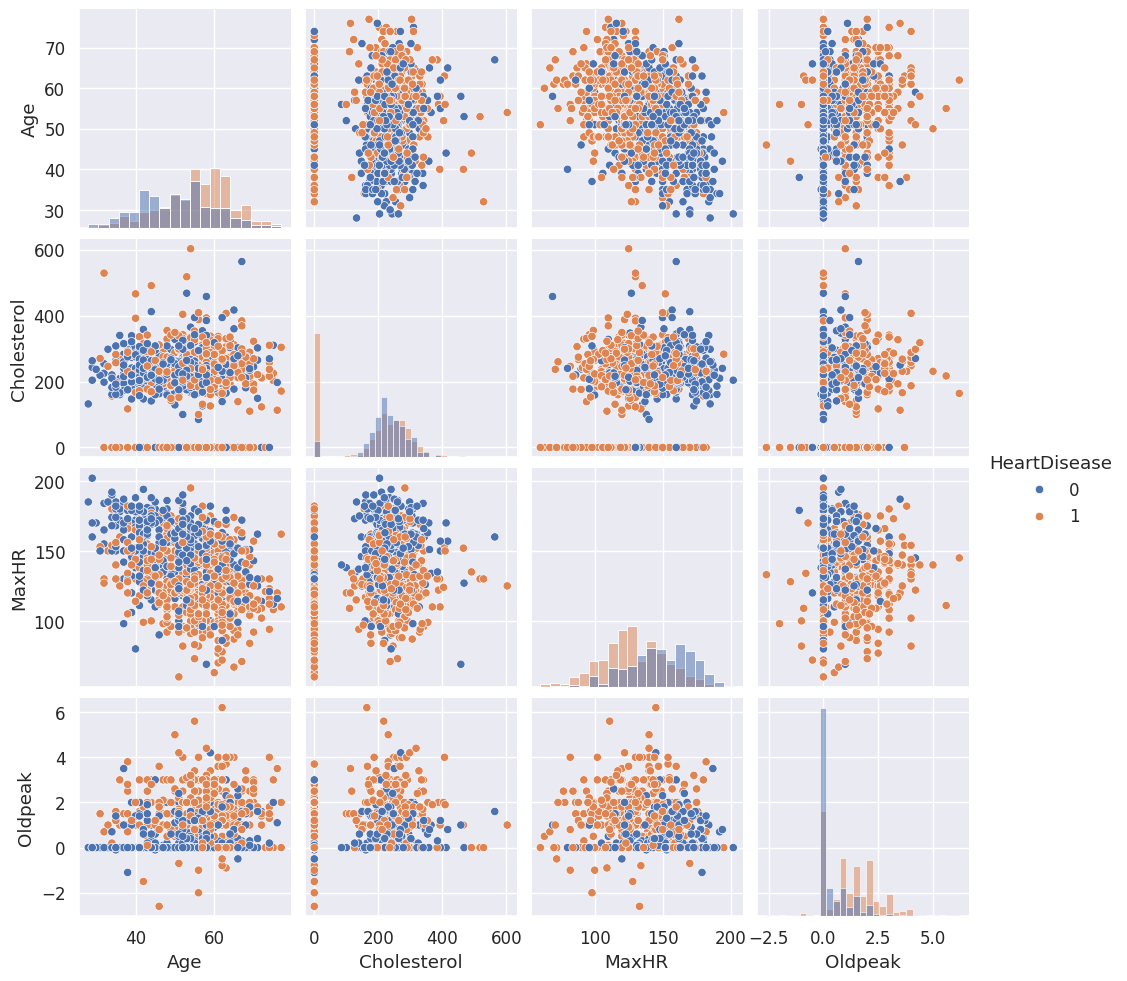

In [19]:
#Pairplot for a Subset of Features
sns.pairplot(df[["Age", "Cholesterol", "MaxHR", "Oldpeak", "HeartDisease"]], hue = "HeartDisease", diag_kind = "hist")
plt.show()

# 6-8 Relationships Between Features and Target Part 02 [Correlation Matrix]

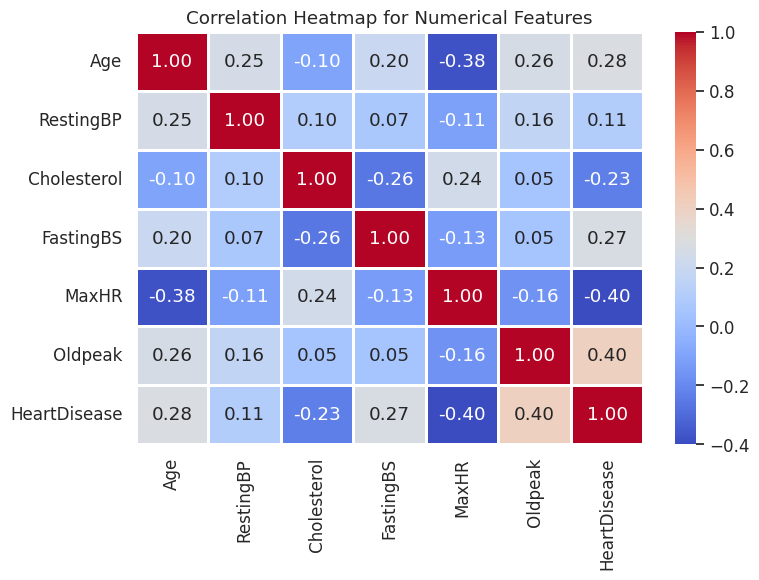

In [25]:
#Correlation Matrix
corr_matrix = df[numeric_col + [target_col]].corr()
#Correlation Heatmap
plt.figure(figsize = (8,6))
sns.heatmap(corr_matrix, annot = True, cmap = "coolwarm", fmt = ".2f", linewidth = 1)
plt.title("Correlation Heatmap for Numerical Features")
plt.tight_layout()
plt.show()

In [26]:
#Correlation values sorted by target
corr_matrix[target_col].sort_values(ascending=False)

,HeartDisease
HeartDisease,1.000000
Oldpeak,0.403951
Age,0.282039
FastingBS,0.267291
RestingBP,0.107589
Cholesterol,-0.232741
MaxHR,-0.400421
